# Document Classification — LightGBM

Trains a LightGBM classifier on hand-crafted text features extracted from the OCR cache.
No TF-IDF — features are regex patterns, structural stats, and keyword flags (~25 total).

In [21]:
%run shared.py
import lightgbm as lgb

## Load Data

In [22]:
df = load_ocr_cache()
df.head()

Loaded from cache: artifacts\ocr_cache.csv
Dataset: (1200, 3)


,path,label,text
0,data\email\1017.png,email,Orginal Message— From: ‘Daragan Karon Sont: Mo...
1,data\email\1025.png,email,"Mee Sint: ‘Tuohy, arr 04, 200074 4 2079066803 ..."
2,data\email\1038.png,email,~Original Message— From: JMWintner@WLRK.com (m...
3,data\email\1063.png,email,Subject: Visit of Professor Peter Grifiths Loc...
4,data\email\1066.png,email,"Lyalls, Teresa M, ine] 000@a0l.com! BCC: Prima..."


## Feature Engineering

Each document is represented by hand-crafted features derived from its OCR text:
- **Structural**: word count, character count, line count, paragraph count, number density
- **Email signals**: From/To/Subject headers, email address count
- **Invoice signals**: invoice/total/VAT keywords, currency symbols, dates, IBAN
- **Questionnaire signals**: question marks, question count, response count
- **Scientific signals**: abstract, references, et al., figure count

In [23]:
X = pd.DataFrame([extract_features(t) for t in df["text"]])
y = df["label"]

print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (1200, 24)


,word_count,char_count,avg_word_len,number_count,number_to_word_ratio,unique_word_ratio,has_from,has_to,has_subject,email_addr_count,...,date_count,has_iban,has_due,question_mark_count,question_count,response_count,has_abstract,has_references,has_et_al,figure_count
0,161,921,4.726708,6,0.037267,0.869565,1,1,0,0,...,0,0,0,1,0,0,0,0,0,0
1,128,700,4.476562,7,0.054688,0.820312,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,53,385,6.283019,5,0.094340,0.981132,1,1,1,5,...,0,0,0,0,0,0,0,0,0,0
3,286,1675,4.860140,23,0.080420,0.804196,0,1,1,0,...,2,0,0,0,0,0,0,0,0,0
4,287,1594,4.557491,40,0.139373,0.655052,0,0,1,1,...,1,0,0,0,0,0,0,0,0,0


## Train-Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:    ", len(X_test))

Training samples: 960
Test samples:     240


## Train LightGBM

In [25]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train, y_train)
print("Training complete.")

Training complete.


## Evaluation

In [26]:
preds = lgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print()
print(classification_report(y_test, preds))

Accuracy: 0.8958333333333334

                precision    recall  f1-score   support

         email       0.92      0.90      0.91        60
       invoice       1.00      1.00      1.00        60
 questionnaire       0.86      0.80      0.83        60
scientific_pub       0.82      0.88      0.85        60

      accuracy                           0.90       240
     macro avg       0.90      0.90      0.90       240
  weighted avg       0.90      0.90      0.90       240



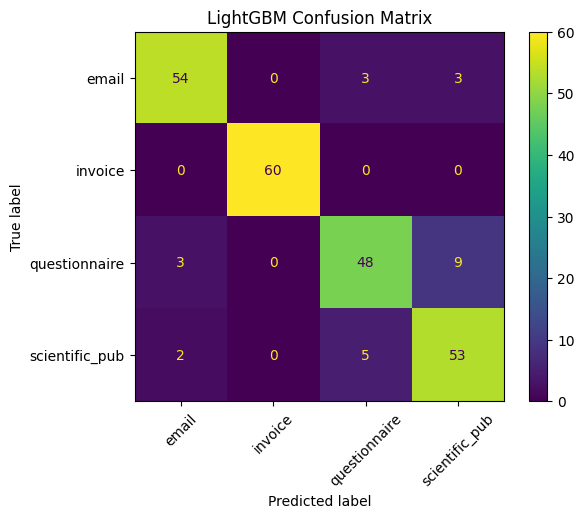

In [27]:
ConfusionMatrixDisplay.from_predictions(y_test, preds, xticks_rotation=45)
plt.title("LightGBM Confusion Matrix")
plt.show()

## Feature Importance

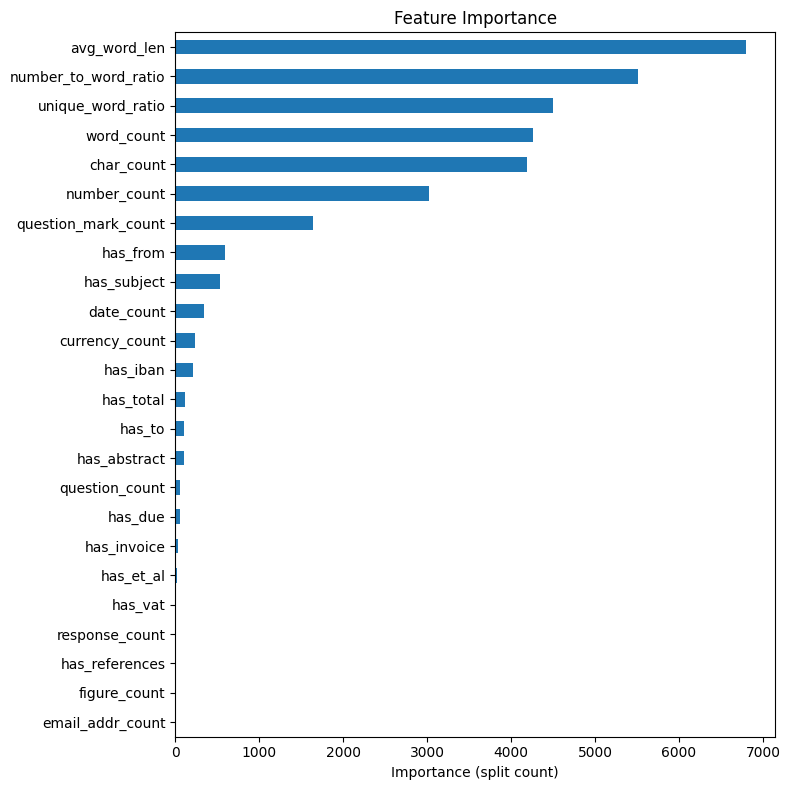

In [28]:
importance = pd.Series(
    lgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

importance.plot(kind="barh", figsize=(8, 8))
plt.title("Feature Importance")
plt.xlabel("Importance (split count)")
plt.tight_layout()
plt.show()

## Save Model

In [29]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

with open(MODELS_DIR / "lgbm_classifier.pkl", "wb") as f:
    pickle.dump(lgb_model, f)

print("Saved to:", MODELS_DIR / "lgbm_classifier.pkl")

Saved to: artifacts\models\lgbm_classifier.pkl
